<a href="https://colab.research.google.com/github/stalidzane/bluesky-mt-discourse/blob/final/02_network_analysis_revised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analysis
Network analysis of Bluesky discourse around machine translation.

**Research questions:**
1. **Sentiment & framing** — Do people talk about MT as a tool, a threat, or both? *(content analysis)*
2. **Professional impact discourse** — How do working translators discuss MT's effect on their careers? *(content analysis)*
3. **Utility vs. displacement tension** — Do people acknowledge MT's utility while lamenting professional erosion? *(content analysis)*
4. **Network structure** — Do professional translators and general users form distinct communities in the follow/reply networks, and which accounts bridge them? *(network analysis — this notebook)*

## Setup

In [1]:
!pip -q install networkx matplotlib pandas scipy

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
from itertools import islice

In [3]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/bluesky-data/'
except ImportError:
    DATA_DIR = './bluesky-data/'  # running outside Colab

Mounted at /content/drive


In [4]:
df = pd.read_csv(DATA_DIR + 'posts_clean.csv')
df_raw = pd.read_csv(DATA_DIR + 'posts_raw.csv')   # needed to resolve reply URIs
df_profiles = pd.read_csv(DATA_DIR + 'author_profiles.csv')
df_graph = pd.read_csv(DATA_DIR + 'graph.csv')
df_reply_raw = pd.read_csv(DATA_DIR + 'reply_edges.csv')

print(f"Posts (clean): {len(df)}")
print(f"Posts (raw):   {len(df_raw)}")
print(f"Profiles:      {len(df_profiles)}")
print(f"Graph edges:   {len(df_graph)} ({df_graph['type'].value_counts().to_dict()})")
print(f"Reply edges:   {len(df_reply_raw)}")

Posts (clean): 3864
Posts (raw):   9349
Profiles:      2303
Graph edges:   133428 ({'follows': 127597, 'reply': 5831})
Reply edges:   7116


## Data cleaning

Two problems must be fixed before any network analysis:

1. **Placeholder accounts.** `handle.invalid` is Bluesky's placeholder for deleted/unresolvable accounts — it is not a real user, and it was previously the top node by degree centrality.
2. **Keyword contamination.** The keyword *MTPE* (machine translation post-editing) also matches Peru's Ministry of Labor (*Ministerio de Trabajo y Promoción del Empleo*), so the collection contains Peruvian labor-ministry posts unrelated to machine translation. The filter below is conservative (requires MTPE **and** Spanish employment/ministry terms in the same post) — coordinate with the content-analysis part so both use the same cleaned set.

In [5]:
# ── 1. Remove placeholder/deleted accounts ─────────────────────
def is_valid_handle(h):
    return isinstance(h, str) and not h.endswith('.invalid')

n_before = len(df)
df = df[df['handle'].map(is_valid_handle)].copy()
df_raw = df_raw[df_raw['handle'].map(is_valid_handle)].copy()
df_graph = df_graph[df_graph['source'].map(is_valid_handle)
                    & df_graph['target'].map(is_valid_handle)].copy()
print(f"Posts dropped (invalid handle): {n_before - len(df)}")

# ── 2. Topic contamination filter (MTPE = Peruvian ministry) ───
peru_terms = r'(?:empleo|laboral|vacante|ministerio|piura|per[uú])'
noise_pattern = rf'(?i)(?:mtpe.*{peru_terms}|{peru_terms}.*mtpe)'
noise_mask = df['text_clean'].fillna('').str.contains(noise_pattern, regex=True)
print(f"Posts dropped (MTPE-ministry noise): {noise_mask.sum()}")
for t in df.loc[noise_mask, 'text_clean'].head(3):
    print(f"  x {t[:100]}")
df = df[~noise_mask].copy()

print(f"\nPosts remaining: {len(df)}")

Posts dropped (invalid handle): 0
Posts dropped (MTPE-ministry noise): 0

Posts remaining: 3864


## Network construction

The follow graph and the reply graph are kept **separate**: following someone and replying to someone are different social relations, and merging them into a single `DiGraph` silently collapses duplicate (source, target) pairs.

The reply graph is **weighted** (repeat interactions between the same pair are preserved as edge weights) and **self-loops are removed** (users replying within their own threads).

In [6]:
# ── Follow graph ────────────────────────────────────────────────
df_follows = df_graph[df_graph['type'] == 'follows']
G_follows = nx.from_pandas_edgelist(
    df_follows, source='source', target='target',
    create_using=nx.DiGraph()
)

# ── Reply graph (weighted, no self-loops) ──────────────────────
uri_to_handle = dict(zip(df_raw['uri'], df_raw['handle']))
df_reply = df_reply_raw.copy()
df_reply['target'] = df_reply['target_uri'].map(uri_to_handle)
df_reply = df_reply.dropna(subset=['target'])
df_reply = df_reply[df_reply['source'].map(is_valid_handle)
                    & df_reply['target'].map(is_valid_handle)]
n_selfloops = (df_reply['source'] == df_reply['target']).sum()
df_reply = df_reply[df_reply['source'] != df_reply['target']]

reply_weights = (df_reply.groupby(['source', 'target'])
                 .size().reset_index(name='weight'))
G_reply = nx.from_pandas_edgelist(
    reply_weights, source='source', target='target',
    edge_attr='weight', create_using=nx.DiGraph()
)

# ── Node attributes ────────────────────────────────────────────
user_type_map = dict(zip(df['handle'], df['user_type']))
post_count_map = df['handle'].value_counts().to_dict()
for G_ in (G_follows, G_reply):
    for node in G_.nodes():
        G_.nodes[node]['user_type'] = user_type_map.get(node, 'unknown')
        G_.nodes[node]['post_count'] = post_count_map.get(node, 0)

print(f"Follow graph: {G_follows.number_of_nodes()} nodes, {G_follows.number_of_edges()} edges")
print(f"Reply graph:  {G_reply.number_of_nodes()} nodes, {G_reply.number_of_edges()} edges "
      f"({int(reply_weights['weight'].sum())} interactions, {n_selfloops} self-replies removed)")

Follow graph: 86162 nodes, 127597 edges
Reply graph:  2642 nodes, 2912 edges (3714 interactions, 2117 self-replies removed)


## Basic graph statistics

> **Sampling caveat.** The full follow graph is an *ego-network sample*: it only contains follow edges crawled around the ~1,000 post authors (and the crawl was capped per account by API pagination — visible as a spike in the raw degree distribution). Global statistics on the full graph therefore reflect the crawl design as much as Bluesky's actual structure. Structural analysis below is restricted to the **post-authors subgraph**, where every node was sampled the same way.

In [7]:
post_authors = set(df['handle'])
G_authors = G_follows.subgraph(post_authors).copy()
G_und = G_authors.to_undirected()

print("=" * 50)
print("FULL FOLLOW GRAPH (crawl sample)")
print("=" * 50)
print(f"Nodes:   {G_follows.number_of_nodes()}")
print(f"Edges:   {G_follows.number_of_edges()}")
print(f"Density: {nx.density(G_follows):.6f}")

print(f"\n{'='*50}")
print("POST-AUTHORS FOLLOW SUBGRAPH")
print("=" * 50)
print(f"Nodes:       {G_authors.number_of_nodes()}")
print(f"Edges:       {G_authors.number_of_edges()}")
print(f"Density:     {nx.density(G_authors):.4f}")
print(f"Reciprocity: {nx.reciprocity(G_authors):.4f}")
print(f"Avg clustering coefficient: {nx.average_clustering(G_und):.4f}")
print(f"Degree assortativity:       {nx.degree_assortativity_coefficient(G_und):.4f}")

wcc = list(nx.weakly_connected_components(G_authors))
lcc_nodes = max(wcc, key=len)
G_lcc_und = G_und.subgraph(lcc_nodes).copy()
print(f"\nWeakly connected components: {len(wcc)}")
print(f"Largest component (LCC):     {len(lcc_nodes)} nodes")
print(f"LCC avg shortest path (undirected): {nx.average_shortest_path_length(G_lcc_und):.2f}")
print(f"LCC diameter (undirected):          {nx.diameter(G_lcc_und)}")

FULL FOLLOW GRAPH (crawl sample)
Nodes:   86162
Edges:   127597
Density: 0.000017

POST-AUTHORS FOLLOW SUBGRAPH
Nodes:       1339
Edges:       1320
Density:     0.0007
Reciprocity: 0.1621
Avg clustering coefficient: 0.0346
Degree assortativity:       0.0155

Weakly connected components: 535
Largest component (LCC):     676 nodes
LCC avg shortest path (undirected): 6.49
LCC diameter (undirected):          20


The post-authors subgraph is very sparse (1,339 nodes, 1,320 edges) and fragmented.
We have 535 weakly connected components, with the largest covering only about half the authors (676 nodes).
Reciprocity (0.16) is low, which is typical of follow networks: attention flows toward visible accounts rather than being mutual.
Clustering (0.035) is higher a random graph of the same density would give, but the average shortest path (6.49) and diameter (20) are in line with a comparable random graph — so there is modest local cohesion above chance, but not strong small-world structure.
In short: this is a loosely connected discourse, not a tight community.

## Centrality — follow network (post authors)

In [8]:
# In-degree = followed by others in the sample (visibility)
# Out-degree = follows others in the sample (engagement)
in_c = nx.in_degree_centrality(G_authors)
out_c = nx.out_degree_centrality(G_authors)
top_in = sorted(in_c.items(), key=lambda x: x[1], reverse=True)[:15]

print("Top 15 by in-degree centrality (most followed within sample):")
print(f"  {'handle':<42} {'in_c':>7} {'out_c':>7}  type")
print("  " + "-" * 68)
for handle, score in top_in:
    utype = user_type_map.get(handle, 'unknown')
    print(f"  {handle:<42} {score:>7.4f} {out_c[handle]:>7.4f}  {utype}")

Top 15 by in-degree centrality (most followed within sample):
  handle                                        in_c   out_c  type
  --------------------------------------------------------------------
  subtleuk.bsky.social                        0.0127  0.0015  professional
  creative-xl8.bsky.social                    0.0112  0.0030  professional
  gametranslator.bsky.social                  0.0105  0.0060  professional
  palavrillo.bsky.social                      0.0090  0.0030  professional
  narush15.bsky.social                        0.0090  0.0007  professional
  alyssaweldon.bsky.social                    0.0082  0.0007  professional
  linguacaps.bsky.social                      0.0082  0.0067  professional
  avue.bsky.social                            0.0067  0.0022  professional
  gitt-workshop.bsky.social                   0.0067  0.0015  professional
  brivaiglesias.bsky.social                   0.0067  0.0007  professional
  cdomingueztrad.com                          0.00

In [9]:
# PageRank — standard influence measure for follow networks:
# being followed by well-followed accounts counts more.
pagerank = nx.pagerank(G_authors, alpha=0.85)
top_pr = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:15]

print("Top 15 by PageRank:")
print(f"  {'handle':<42} {'pagerank':>9}  type")
print("  " + "-" * 62)
for handle, score in top_pr:
    utype = user_type_map.get(handle, 'unknown')
    print(f"  {handle:<42} {score:>9.4f}  {utype}")

Top 15 by PageRank:
  handle                                      pagerank  type
  --------------------------------------------------------------
  alyssaweldon.bsky.social                      0.0113  professional
  guerrillamedia.bsky.social                    0.0106  general
  reporterdem.bsky.social                       0.0106  general
  narush15.bsky.social                          0.0102  professional
  gitt-workshop.bsky.social                     0.0099  professional
  fbk-mt.bsky.social                            0.0097  professional
  geiongallego.bsky.social                      0.0090  unknown
  cdomingueztrad.com                            0.0073  professional
  fiteurope.bsky.social                         0.0067  professional
  thewrongsideoftime.bsky.social                0.0064  general
  mtkopon.bsky.social                           0.0064  professional
  siree.sh                                      0.0058  tech
  rystorm.com                                   0.0052

In [10]:
# Betweenness centrality (bridges between groups)
betweenness = nx.betweenness_centrality(G_authors, normalized=True)
top_between = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 by betweenness centrality (bridges between groups):")
print(f"  {'handle':<42} {'between':>8}  type")
print("  " + "-" * 62)
for handle, score in top_between:
    utype = user_type_map.get(handle, 'unknown')
    print(f"  {handle:<42} {score:>8.4f}  {utype}")

Top 10 by betweenness centrality (bridges between groups):
  handle                                      between  type
  --------------------------------------------------------------
  toastcrust.bsky.social                       0.0046  general
  aulet.es                                     0.0045  professional
  jentranslations.bsky.social                  0.0043  professional
  tamslator.eurosky.social                     0.0042  general
  mistygaltees.bsky.social                     0.0035  professional
  jemediatranslation.bsky.social               0.0033  professional
  thewrongsideoftime.bsky.social               0.0033  general
  cdomingueztrad.com                           0.0031  professional
  qvotoms.bsky.social                          0.0030  general
  laetecks.bsky.social                         0.0029  general


In [11]:
# Closeness centrality — computed on the LCC only (meaningless on
# disconnected graphs). Directed: closeness uses incoming distances.
G_authors_lcc = G_authors.subgraph(lcc_nodes).copy()
closeness = nx.closeness_centrality(G_authors_lcc)
top_closeness = sorted(closeness.items(), key=lambda x: x[1], reverse=True)[:15]

print(f"Closeness centrality on LCC ({G_authors_lcc.number_of_nodes()} nodes):")
print(f"  {'handle':<42} {'closeness':>10}  type")
print("  " + "-" * 64)
for handle, score in top_closeness:
    utype = user_type_map.get(handle, 'unknown')
    print(f"  {handle:<42} {score:>10.4f}  {utype}")

Closeness centrality on LCC (676 nodes):
  handle                                      closeness  type
  ----------------------------------------------------------------
  alyssaweldon.bsky.social                       0.0641  professional
  subtleuk.bsky.social                           0.0640  professional
  scanomendez.bsky.social                        0.0603  general
  cdomingueztrad.com                             0.0600  professional
  apolline.bsky.social                           0.0599  professional
  atanet.org                                     0.0585  professional
  creative-xl8.bsky.social                       0.0581  professional
  marsaliath.bsky.social                         0.0576  general
  aulet.es                                       0.0576  professional
  narush15.bsky.social                           0.0573  professional
  guerrillamedia.bsky.social                     0.0571  general
  palavrillo.bsky.social                         0.0564  professional
  sla

## Centrality — reply network

In [12]:
# Weighted in-degree = total replies received (conversation attention)
w_in = dict(G_reply.in_degree(weight='weight'))
top_reply = sorted(w_in.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 most replied-to users (weighted):")
print(f"  {'handle':<42} {'replies':>7}  type")
print("  " + "-" * 60)
for handle, deg in top_reply:
    utype = user_type_map.get(handle, 'unknown')
    print(f"  {handle:<42} {deg:>7}  {utype}")

Top 10 most replied-to users (weighted):
  handle                                     replies  type
  ------------------------------------------------------------
  tobyfox.undertale.com                          364  general
  bcmerchant.bsky.social                          65  general
  tamslator.eurosky.social                        46  general
  barleybap.bsky.social                           46  professional
  liabelle.me                                     45  general
  eurosky.social                                  36  general
  gandersocial.ca                                 33  unknown
  blazingwaters.myatproto.social                  30  general
  modilingua.bsky.social                          28  professional
  olivierroth.bsky.social                         27  professional


The reply network is dominated by a single outlier (`tobyfox.undertale.com`, one viral thread attracting hundreds of replies from outside the translation community). This is an event, not a structural property — the analysis below reports results with the outlier noted, and the visualization is restricted to post authors so the viral spike does not swamp the layout. In the follow network, professional translators rank highly on betweenness and closeness, suggesting they act as bridges between the professional and general-audience parts of the discourse (→ RQ4).

## Community detection

All algorithms are run **on the same graph** — the undirected largest connected component of the post-authors follow subgraph — so their modularity scores are directly comparable. Running detection on the full fragmented graph (438 components) previously produced ~230 "communities", most of which were just disconnected fragments of 2–5 nodes, inflating modularity.

In [13]:
G_cd = G_lcc_und  # undirected LCC of post-authors follow subgraph
print(f"Community detection graph: {G_cd.number_of_nodes()} nodes, {G_cd.number_of_edges()} edges")

MIN_SIZE = 5  # communities smaller than this are noise for our purposes

# ── Louvain ─────────────────────────────────────────────────────
communities_louvain = sorted(nx.community.louvain_communities(G_cd, seed=42),
                             key=len, reverse=True)

# ── Greedy Modularity ──────────────────────────────────────────
communities_greedy = sorted(nx.community.greedy_modularity_communities(G_cd),
                            key=len, reverse=True)

# ── FluidC (k fixed to the number of non-trivial Louvain communities) ──
k_fluid = max(2, sum(1 for c in communities_louvain if len(c) >= MIN_SIZE))
communities_fluid = sorted(nx.community.asyn_fluidc(G_cd, k=k_fluid, seed=42),
                           key=len, reverse=True)

Community detection graph: 676 nodes, 1082 edges


In [14]:
print("Running Girvan-Newman")
gn_gen = nx.community.girvan_newman(G_cd)
best_gn_communities, best_gn_mod = None, -1
for partition in islice(gn_gen, len(communities_louvain) + 2):
    mod = nx.community.modularity(G_cd, partition)
    if mod > best_gn_mod:
        best_gn_mod = mod
        best_gn_communities = list(partition)
best_gn_communities = sorted(best_gn_communities, key=len, reverse=True)
print("Girvan-Newman done.")

Running Girvan-Newman
Girvan-Newman done.


In [15]:
# ── Comparison (all on the same graph → comparable) ───────────
def n_nontrivial(comms):
    return sum(1 for c in comms if len(c) >= MIN_SIZE)

rows = [
    ("Louvain",           communities_louvain, nx.community.modularity(G_cd, communities_louvain)),
    ("Greedy Modularity", communities_greedy,  nx.community.modularity(G_cd, communities_greedy)),
    ("FluidC",            communities_fluid,   nx.community.modularity(G_cd, communities_fluid)),
    ("Girvan-Newman",     best_gn_communities, best_gn_mod),
]

print(f"{'Method':<22} {'k':>4} {'k(size>=5)':>11} {'Modularity':>12}")
print("-" * 55)
for name, comms, mod in rows:
    print(f"{name:<22} {len(comms):>4} {n_nontrivial(comms):>11} {mod:>12.4f}")

Method                    k  k(size>=5)   Modularity
-------------------------------------------------------
Louvain                  17          17       0.7327
Greedy Modularity        21          18       0.7351
FluidC                   17          17       0.6722
Girvan-Newman            19          18       0.7048


In [16]:
# Use Louvain as primary partition for downstream analysis
communities = [c for c in communities_louvain if len(c) >= MIN_SIZE]
node_community = {node: i for i, comm in enumerate(communities) for node in comm}
df['community'] = df['handle'].map(node_community)

print(f"Non-trivial communities (size >= {MIN_SIZE}): {len(communities)}")
print(f"Posts covered: {df['community'].notna().sum()} / {len(df)}")

Non-trivial communities (size >= 5): 17
Posts covered: 1571 / 3864


In [17]:
print("User type breakdown + sample posts per community (top 5):\n")
for i in range(min(5, len(communities))):
    comm_df = df[df['community'] == i]
    if comm_df.empty:
        continue
    print(f"-- Community {i+1} ({len(communities[i])} nodes, {len(comm_df)} posts) --")
    print(comm_df['user_type'].value_counts().to_string())
    print("Sample posts:")
    n_sample = min(3, len(comm_df))
    for t in comm_df['text_clean'].dropna().sample(n_sample, random_state=42).tolist():
        print(f"  - {t[:110]}")
    print()

User type breakdown + sample posts per community (top 5):

-- Community 1 (96 nodes, 345 posts) --
user_type
general         237
professional     69
unknown          22
tech             17
Sample posts:
  - Good news: AI hasn't replaced human translators. But it replaced the job they used to do. Post-editing, QA, da
  - 📦 ppl/ppl-deepl-v3-requests 12.4.2 TYPO3 14 service package for DeepL V3 REST text, glossary, style rule and d
  - 📦 mominalzaraa/filament-localization v2.0.2 The first and only automatic Filament localization package with in

-- Community 2 (91 nodes, 235 posts) --
user_type
professional    125
general         107
tech              3
Sample posts:
  - Exactly. These are the use cases I'll be talking about in my presentations at the Mexican Translators Organiza
  - That's the question. Option 3 isn't going to happen - everyone has been dealing with crappy manuals translated
  - Save price watches → Ahorre precio relojes #machinetranslation

-- Community 3 (48 nodes, 90 

The partition is robust: Louvain (0.737), Greedy Modularity (0.735) and Girvan–Newman (0.705) agree closely, and FluidC (0.664) is not far behind despite its fixed *k*. Of the 16 non-trivial communities, **Community 1 (109 nodes) is the only professional-majority one**: its posts (147 professional vs. 116 general) center on industry topics — MTPE rates, working conditions, translation-industry news, with a visible Spanish-language professional contingent. Communities 2–5 are all general-dominated and organized by **topic/fandom context rather than profession**: game localization and Steam store translations (C3), DeepL/ChatGPT use in game development and fan translation (C4), RPG/game-menu translation (C5), and a mixed developer/localization-tooling cluster (C2).

For **RQ4**, this means the answer is asymmetric: professional translators concentrate in one cohesive community, while general users do not form a single opposing bloc — they scatter across many consumer/fandom pockets where MT is discussed in the context of specific products. The MT debate on Bluesky is therefore less "professionals vs. the public" and more "one professional hub surrounded by many independent fan/consumer conversations."

Note that only 1,566 of 3,864 posts (~40%) fall inside non-trivial communities — the rest belong to authors outside the LCC or in tiny fragments — so this characterization describes the connected core of the discourse.

## Visualizations

Reply network viz: 99 nodes, 176 edges


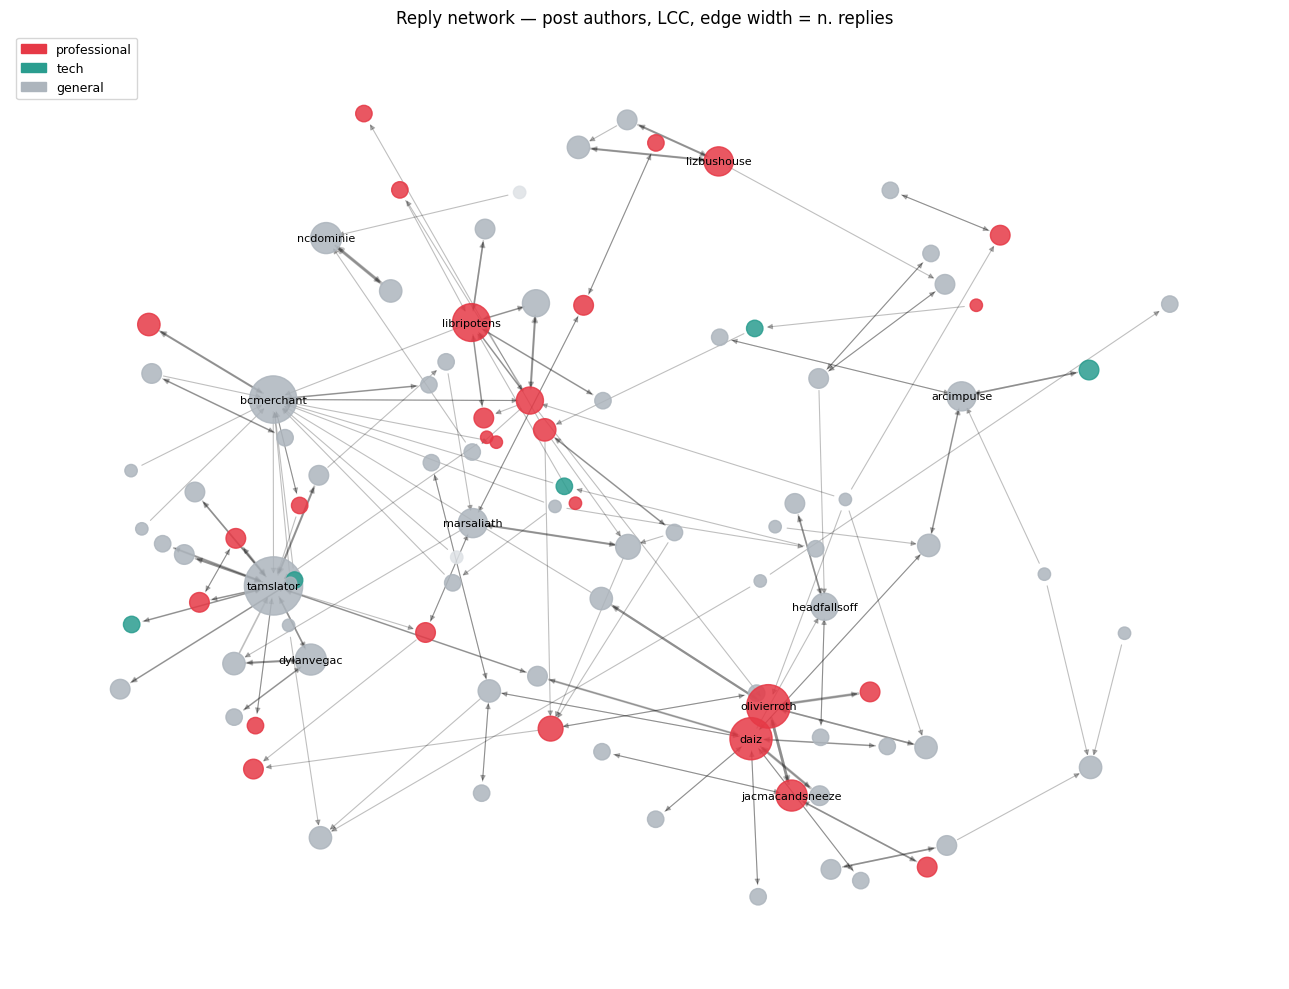

In [18]:
# Reply network — post authors, self-loops already removed,
# degree >= 2, largest weakly connected component only.
color_map = {
    'professional': '#e63946',
    'tech':         '#2a9d8f',
    'general':      '#adb5bd',
    'unknown':      '#dee2e6',
}

nodes_keep = [n for n in G_reply.nodes()
              if n in post_authors and G_reply.degree(n) >= 2]
G_reply_viz = G_reply.subgraph(nodes_keep).copy()
lcc_r = max(nx.weakly_connected_components(G_reply_viz), key=len)
G_reply_viz = G_reply_viz.subgraph(lcc_r).copy()
print(f"Reply network viz: {G_reply_viz.number_of_nodes()} nodes, {G_reply_viz.number_of_edges()} edges")

pos = nx.spring_layout(G_reply_viz, seed=42, k=0.35)
w_in_viz = dict(G_reply_viz.in_degree(weight='weight'))
node_colors = [color_map.get(user_type_map.get(n, 'unknown'), '#dee2e6')
               for n in G_reply_viz.nodes()]
node_sizes = [80 + w_in_viz.get(n, 0) * 60 for n in G_reply_viz.nodes()]
edge_widths = [0.4 + 0.4 * G_reply_viz[u][v]['weight'] for u, v in G_reply_viz.edges()]

fig, ax = plt.subplots(figsize=(13, 10))
nx.draw_networkx_nodes(G_reply_viz, pos, node_color=node_colors,
                       node_size=node_sizes, alpha=0.85, ax=ax)
nx.draw_networkx_edges(G_reply_viz, pos, alpha=0.25, arrows=True,
                       arrowsize=8, width=edge_widths, ax=ax)

# Label the 12 most replied-to accounts
top12 = sorted(w_in_viz, key=w_in_viz.get, reverse=True)[:12]
labels = {n: n.split('.')[0] for n in top12}
nx.draw_networkx_labels(G_reply_viz, pos, labels=labels, font_size=8, ax=ax)

legend_patches = [Patch(color=c, label=t) for t, c in color_map.items() if t != 'unknown']
ax.legend(handles=legend_patches, loc='upper left', fontsize=9)
ax.set_title("Reply network — post authors, LCC, edge width = n. replies", fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.savefig(DATA_DIR + 'reply_network.png', dpi=150, bbox_inches='tight')
plt.show()

Community viz: 455 nodes, 641 intra- + 65 inter-community edges


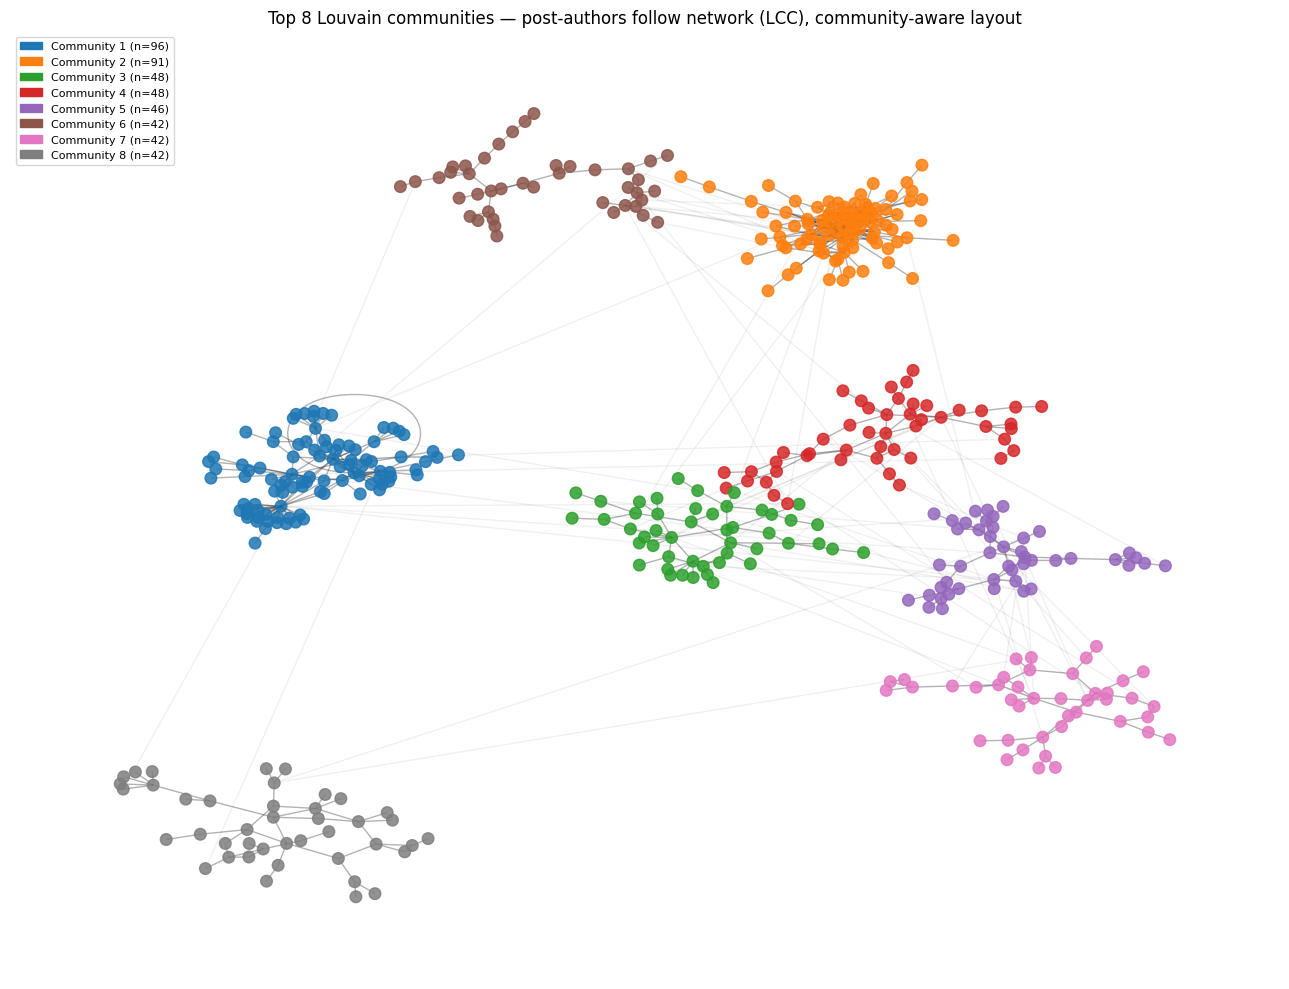

In [19]:
# Community graph — top 8 Louvain communities, community-aware layout.
# A plain spring layout intermixes the communities visually even though
# modularity is high, so instead: (1) lay out one super-node per community
# (weighted by inter-community edge counts), (2) lay out each community's
# nodes locally, (3) offset each local layout to its super-node position.
# Intra-community edges are drawn darker than inter-community ones.
TOP_N = min(8, len(communities))
community_colors = plt.cm.tab10.colors

top_nodes = set().union(*communities[:TOP_N]) if TOP_N else set()
G_comm_viz = G_cd.subgraph(top_nodes).copy()

intra = [(u, v) for u, v in G_comm_viz.edges() if node_community[u] == node_community[v]]
inter = [(u, v) for u, v in G_comm_viz.edges() if node_community[u] != node_community[v]]
print(f"Community viz: {G_comm_viz.number_of_nodes()} nodes, "
      f"{len(intra)} intra- + {len(inter)} inter-community edges")

# ── (1) Super-node layout: one node per community ──────────────
G_super = nx.Graph()
G_super.add_nodes_from(range(TOP_N))
for u, v in inter:
    cu, cv = node_community[u], node_community[v]
    w = G_super.get_edge_data(cu, cv, default={'weight': 0})['weight']
    G_super.add_edge(cu, cv, weight=w + 1)
pos_super = nx.spring_layout(G_super, seed=42, weight='weight', k=1.5, scale=4.0)

# ── (2)+(3) Local layouts, offset to super-node positions ──────
pos = {}
for i in range(TOP_N):
    sub = G_comm_viz.subgraph(communities[i])
    pos_local = nx.spring_layout(sub, seed=42, scale=0.85)
    for n, p in pos_local.items():
        pos[n] = p + pos_super[i]

node_colors = [community_colors[node_community[n] % 10] for n in G_comm_viz.nodes()]

fig, ax = plt.subplots(figsize=(13, 10))
nx.draw_networkx_nodes(G_comm_viz, pos, node_color=node_colors,
                       node_size=70, alpha=0.85, ax=ax)
nx.draw_networkx_edges(G_comm_viz, pos, edgelist=intra, alpha=0.3, ax=ax)
nx.draw_networkx_edges(G_comm_viz, pos, edgelist=inter, alpha=0.06, ax=ax)

legend_patches = [Patch(color=community_colors[i % 10],
                        label=f"Community {i+1} (n={len(communities[i])})")
                  for i in range(TOP_N)]
ax.legend(handles=legend_patches, loc='upper left', fontsize=8)
ax.set_title(f"Top {TOP_N} Louvain communities — post-authors follow network (LCC), "
             "community-aware layout", fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.savefig(DATA_DIR + 'communities.png', dpi=150, bbox_inches='tight')
plt.show()

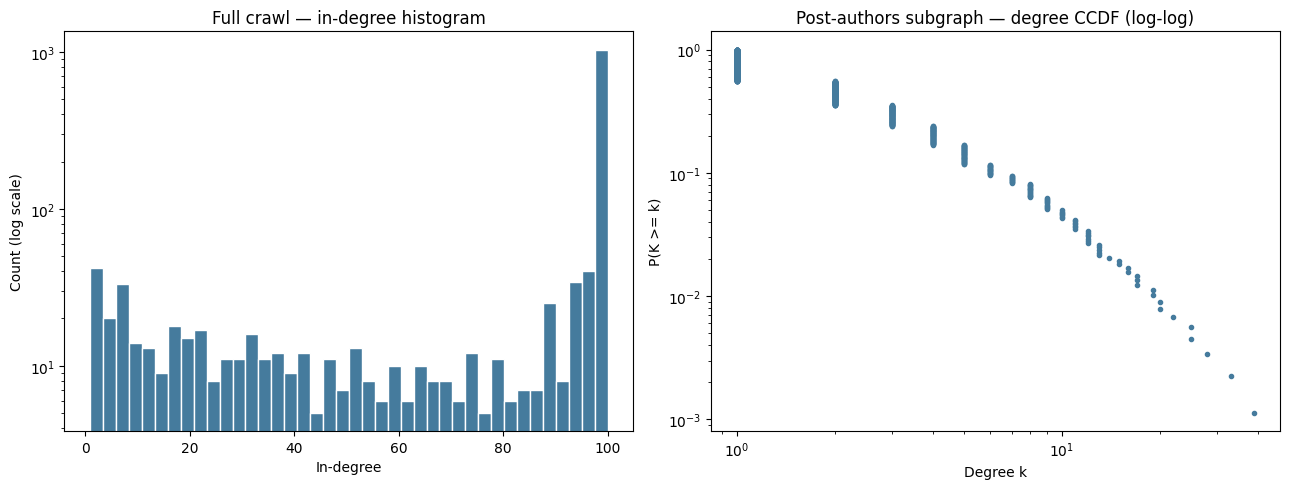

In [20]:
# Degree distribution — two views:
# (1) raw in-degree histogram of the full crawl, annotated: the spike
#     near 100 is the API pagination cap, i.e., a collection artifact;
# (2) log-log CCDF on the post-authors subgraph (the standard view).
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

in_degrees_full = [d for _, d in G_follows.in_degree() if d > 0]
ax1.hist(in_degrees_full, bins=40, color='#457b9d', edgecolor='white', log=True)
ax1.set_xlabel("In-degree")
ax1.set_ylabel("Count (log scale)")
ax1.set_title("Full crawl — in-degree histogram")

degs = np.array(sorted(d for _, d in G_authors.degree() if d > 0))
ccdf = 1.0 - np.arange(len(degs)) / len(degs)
ax2.loglog(degs, ccdf, marker='.', linestyle='none', color='#457b9d')
ax2.set_xlabel("Degree k")
ax2.set_ylabel("P(K >= k)")
ax2.set_title("Post-authors subgraph — degree CCDF (log-log)")

plt.tight_layout()
plt.savefig(DATA_DIR + 'degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary of findings

**Structure:** The post-authors follow subgraph (1,339 nodes, 1,320 edges, density 0.0007) is sparse and fragmented: 535 weakly connected components, with the largest connected component covering 676 nodes (~half the authors). Reciprocity is low (0.16), as expected in follow networks. Clustering (0.035) sits well above the random-graph expectation, but path lengths (avg 6.49, diameter 20) do not — evidence for modest local cohesion, not for strong small-world structure. The MT discourse on Bluesky is a loosely connected space rather than one tight community.

**Central actors:** Follow attention concentrates overwhelmingly on professionals: 13 of the top 15 accounts by in-degree and 10 of the top 15 by closeness are professional translators. PageRank is more mixed, adding general-audience and institutional accounts (e.g., journalism and MT-research accounts). Betweenness splits exactly 5/5 between professional and general accounts — professionals occupy bridging positions between the professional and general parts of the network, but do not monopolize them (→ RQ4). Strikingly, the reply network inverts this picture: the most replied-to accounts are mostly general users, led by one viral outlier (`tobyfox.undertale.com`, 364 replies — 10× the runner-up). Professionals are followed; virality happens around general accounts.

**Communities:** Louvain finds 16 non-trivial communities (modularity 0.737), consistent across three other algorithms run on the same graph. Only one community is professional-majority — an industry-focused cluster (MTPE rates, working conditions, translation-industry news, partly Spanish-language). The remaining large communities are general-dominated and organized by topic/fandom (game localization, fan translation, developer tooling) rather than by profession. Answer to RQ4: professionals form one cohesive hub; general users scatter across many product-centered pockets, with a mixed set of accounts bridging the two.

**Caveats:** (1) The full follow graph is an ego-network sample around post authors, with a per-account crawl cap visible as the spike at in-degree ≈ 100 in the degree histogram — global statistics reflect crawl design, which is why structural analysis is restricted to the post-authors subgraph. (2) Half the post authors fall outside the LCC, and only ~40% of posts belong to non-trivial communities, so community-level conclusions describe the connected core of the discourse. (3) Reply-network statistics are dominated by a single viral thread; it is noted as an event and excluded from the reply-network visualization (post authors with degree ≥ 2 only).